# coadded spectra in 1 obsid

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 3207
download_chandra_obsid 3207 
chandra_repro 3207 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  597.1 kb/s
  oif      fits       28 Kb  ####################          < 1 s  1067.7 kb/s
  vv       pdf        38 Kb  ####################          < 1 s  307.7 kb/s
  cntr_img fits      250 Kb  ####################          < 1 s  3662.2 kb/s
  cntr_img jpg       847 Kb  ####################          < 1 s  5061.6 kb/s
  evt2     fits       21 Mb  ####################          < 1 s  32793.8 kb/s
  full_img fits       76 Kb  ####################          < 1 s  2930.0 kb/s
  full_img jpg        60 Kb  ####################          < 1 s  5638.6 kb/s
  bpix     fits       77 Kb  ####################          < 1 s  1561.1 kb/s
  fov      fits        6 Kb  ####################          < 1 s  732.5 kb/s
  eph1     fits      281 Kb  ####################          < 1 s 

In [3]:
dmcopy "acisf03207_repro_evt2.fits[ccd_id=7]" c7.evt clob+
fluximage c7.evt ./ bin=1 clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf131209709N003_asol1.fits found.
Bad-pixel file acisf03207_repro_bpix1.fits found.
Mask file acisf03207_000N003_msk1.fits found.

The output images will have 1312 by 1312 pixels, pixel size of 0.492 arcsec,
    and cover x=3361.5:4673.5:1,y=3153.5:4465.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 3207
Creating instrument map for obsid 3207
Creating exposure map for obsid 3207
Thresholding data for obsid 3207
Exposure-correcting image for obsid 3207

The following files were created:

 The clipped counts image is:
     ./broad_thresh.img

 The clipped exposure map is:
     ./broad_thresh.expmap

 The exposure-corrected image is:
     ./broad_flux.img



In [4]:
mkpsfmap broad_thresh.img broad_thresh.psfmap 1.49 ecf=0.393 clob+


In [5]:
punlearn wavdetect
pset wavdetect infile=broad_thresh.img
pset wavdetect outfile=wav.fits
pset wavdetect scellfile=wav.scell
pset wavdetect imagefile=wav.img
pset wavdetect defnbkgfile=wav.nbkg
pset wavdetect scales="2 4 8 16 32 64"
pset wavdetect psffile=broad_thresh.psfmap
pset wavdetect expfile=broad_thresh.expmap
pset wavdetect regfile=wav.reg
wavdetect mode=h clobber=yes

In [6]:
dmlist wav.fits counts

44      


In [7]:
dmlist "wav.fits[exclude pos=circle(4070,3945,20)]" counts

41      


In [8]:
dmcopy "wav.fits[exclude pos=circle(4070,3945,20)]" no-clus.fits clob+
dmstat "no-clus.fits[cols net_counts]"

NET_COUNTS[count]
    min:	5.5486564636 	      @:	40 
    max:	497.16427612 	      @:	28 
   mean:	57.304732497 
  sigma:	85.151699452 
    sum:	2349.4940324 
   good:	41 
   null:	0 



In [9]:
dmlist "no-clus.fits[net_counts=100:]" counts

8       


In [10]:
dmcopy "no-clus.fits[net_counts=100:]" src.fits clob+

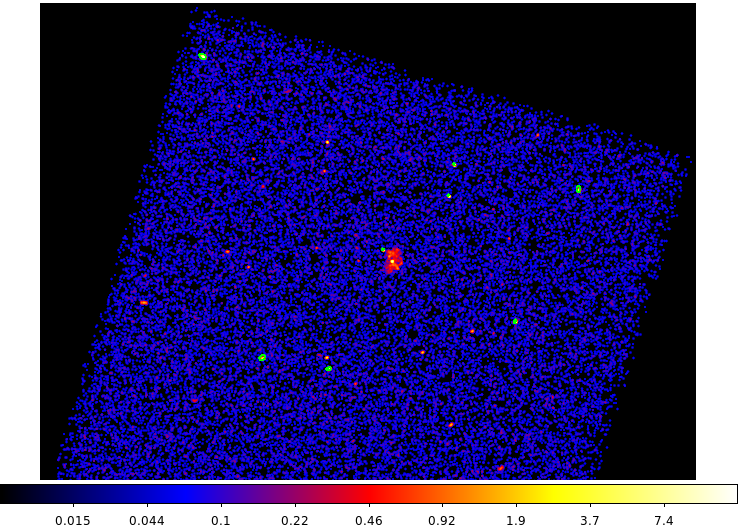

In [11]:
ds9 -region width 2 broad_thresh.img -smooth -scale log -cmap b \
     -zoom 0.5 -pan to 4020 3990 physical -region src.fits \
     -saveimage png ds9_01.png -quit
    
display < ds9_01.png

In [12]:
dmmakereg region="region(src.fits)" out=src.reg kernel=ascii clob+
cat src.reg

# Region file format: DS9 version 3.0
global color=blue font="helvetica 10 normal" select=1 edit=1 move=1 delete=1 include=1 fixed=0
physical;Ellipse(3939.65,3732.18,5.30179,3.19864,15.4853) #  
physical;Ellipse(3806.98,3754.33,7.08125,4.18562,26.0989) #  
physical;Ellipse(4312.56,3827.05,3.9379,2.64072,50.7592) #  
physical;Ellipse(4048.22,3970.57,2.44139,1.96386,20.4309) #  
physical;Ellipse(4179.67,4078.33,2.33642,2.05695,9.03762) #  
physical;Ellipse(4439.89,4091.26,6.46662,3.97055,92.5572) #  
physical;Ellipse(4190.34,4140.68,2.40601,2.13286,46.3592) #  
physical;Ellipse(3687.97,4356.76,7.13883,4.4737,149.623) #  


In [13]:
grep physical src.reg | sed  \
  -e "s:^physical;:acisf03207_repro_evt2.fits[sky=:" \
  -e "s/Ellipse/ellipse/" \
  -e "s/ #/]/" > multi.lis

cat multi.lis

acisf03207_repro_evt2.fits[sky=ellipse(3939.65,3732.18,5.30179,3.19864,15.4853)]  
acisf03207_repro_evt2.fits[sky=ellipse(3806.98,3754.33,7.08125,4.18562,26.0989)]  
acisf03207_repro_evt2.fits[sky=ellipse(4312.56,3827.05,3.9379,2.64072,50.7592)]  
acisf03207_repro_evt2.fits[sky=ellipse(4048.22,3970.57,2.44139,1.96386,20.4309)]  
acisf03207_repro_evt2.fits[sky=ellipse(4179.67,4078.33,2.33642,2.05695,9.03762)]  
acisf03207_repro_evt2.fits[sky=ellipse(4439.89,4091.26,6.46662,3.97055,92.5572)]  
acisf03207_repro_evt2.fits[sky=ellipse(4190.34,4140.68,2.40601,2.13286,46.3592)]  
acisf03207_repro_evt2.fits[sky=ellipse(3687.97,4356.76,7.13883,4.4737,149.623)]  


## One spectra for each source

In [14]:
punlearn specextract
pset specextract infile=@multi.lis
pset specextract outroot=3c294
pset specextract weight=no
pset specextract correctpsf=yes
pset specextract combine=no
specextract mode=h clob+


Running specextract
Version: 30 November 2016

Using event file acisf03207_repro_evt2.fits[sky=ellipse(3939.65,3732.18,5.30179,3.19864,15.4853)]

Aspect solution file pcadf131209709N003_asol1.fits found.

Bad-pixel file acisf03207_repro_bpix1.fits found.

Mask file acisf03207_000N003_msk1.fits found.

Using event file acisf03207_repro_evt2.fits[sky=ellipse(3806.98,3754.33,7.08125,4.18562,26.0989)]

Aspect solution file pcadf131209709N003_asol1.fits found.

Bad-pixel file acisf03207_repro_bpix1.fits found.

Mask file acisf03207_000N003_msk1.fits found.

Using event file acisf03207_repro_evt2.fits[sky=ellipse(4312.56,3827.05,3.9379,2.64072,50.7592)]

Aspect solution file pcadf131209709N003_asol1.fits found.

Bad-pixel file acisf03207_repro_bpix1.fits found.

Mask file acisf03207_000N003_msk1.fits found.

Using event file acisf03207_repro_evt2.fits[sky=ellipse(4048.22,3970.57,2.44139,1.96386,20.4309)]

Aspect solution file pcadf131209709N003_asol1.fits found.

Bad-pixel file acisf03207_re

In [15]:
/bin/ls 3c294_src*.pi | grep -v _grp > src.lis
cat src.lis

3c294_src1.pi
3c294_src2.pi
3c294_src3.pi
3c294_src4.pi
3c294_src5.pi
3c294_src6.pi
3c294_src7.pi
3c294_src8.pi


In [16]:
pset combine_spectra src_spectra=@src.lis
pset combine_spectra out=3c294_combined
pset combine_spectra method=avg

combine_spectra mode=h clob+

Prepared to combine 8 spectra

source PHA: 3c294_src1.pi
       ARF: 3c294_src1.corr.arf
       RMF: 3c294_src1.rmf
source PHA: 3c294_src2.pi
       ARF: 3c294_src2.corr.arf
       RMF: 3c294_src2.rmf
source PHA: 3c294_src3.pi
       ARF: 3c294_src3.corr.arf
       RMF: 3c294_src3.rmf
source PHA: 3c294_src4.pi
       ARF: 3c294_src4.corr.arf
       RMF: 3c294_src4.rmf
source PHA: 3c294_src5.pi
       ARF: 3c294_src5.corr.arf
       RMF: 3c294_src5.rmf
source PHA: 3c294_src6.pi
       ARF: 3c294_src6.corr.arf
       RMF: 3c294_src6.rmf
source PHA: 3c294_src7.pi
       ARF: 3c294_src7.corr.arf
       RMF: 3c294_src7.rmf
source PHA: 3c294_src8.pi
       ARF: 3c294_src8.corr.arf
       RMF: 3c294_src8.rmf

The following files were created:
  3c294_combined_src.pi
  3c294_combined_src.arf
  3c294_combined_src.rmf


## Weighted sum

In [17]:
punlearn specextract
pset specextract infile="acisf03207_repro_evt2.fits[sky=region(src.fits)]"
pset specextract outroot=combined
specextract mode=h clob+

Running specextract
Version: 30 November 2016

Using event file acisf03207_repro_evt2.fits[sky=region(src.fits)]

Aspect solution file pcadf131209709N003_asol1.fits found.

Bad-pixel file acisf03207_repro_bpix1.fits found.

Mask file acisf03207_000N003_msk1.fits found.

Setting bad pixel file 

Extracting src spectra 

Creating src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of combined.pi with RESPFILE and ANCRFILE keywords.

Updating header of combined_grp.pi with RESPFILE and ANCRFILE keywords.



In [18]:
/bin/ls combined*

combined.arf  combined.pi  combined.rmf  combined_grp.pi


## Fitting

read ARF file 3c294_combined_src.arf
read RMF file 3c294_combined_src.rmf
read ARF file combined.arf
read RMF file combined.rmf


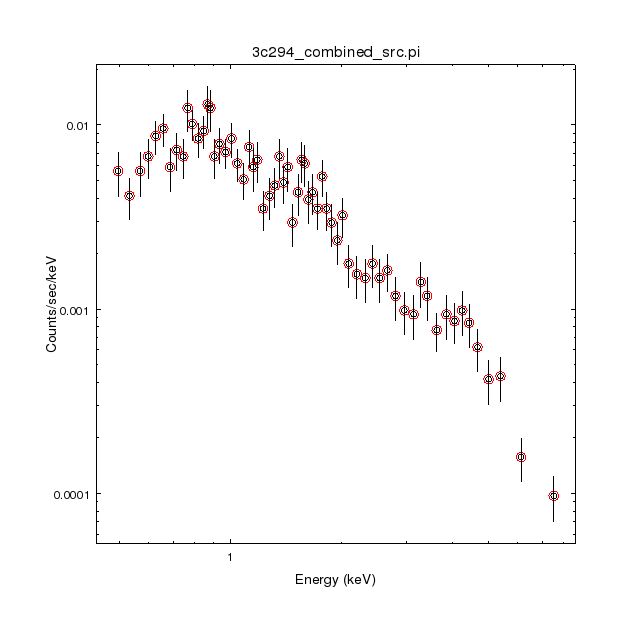

In [19]:
cat << EOM > s1.py
load_pha("3c294_combined_src.pi")
d=get_data()
d.exposure = d.exposure
load_pha(2, "combined.pi")
notice(0.5, 7)
group_counts(1, 20)
group_counts(2, 20)
plot_data(1)
set_curve(["*.color", "red", "symbol.size", 5])
plot_data(2, overplot=True)
log_scale()
print_window("sherpa_01.png","export.clobber=True")
quit()
EOM

sherpa -n s1.py
display < sherpa_01.png